# Problems 8.3 and 8.4: Many-Particle Dynamics with Lennard-Jones

This notebook works through Problems 8.3 (approach to equilibrium) and 8.4 (sensitivity to initial conditions) from Chapter 8. The pieces (Verlet update, minimum-image distances, LJ force) are the same ideas from my previous notebook, rewritten here as **2D** functions using `Lx, Ly` as globals so that Problem 8.3(c) can use a rectangular 20 by 10 box without any extra machinery.

## Setup: 2D Velocity-Verlet + Lennard-Jones

Everything below uses reduced LJ units: $\epsilon = \sigma = m = k_B = 1$. In 2D the equipartition theorem gives $\langle KE \rangle = N k_B T$ (two quadratic degrees of freedom per particle), so the kinetic temperature is
$$T = \frac{1}{2N} \sum_i (v_{x,i}^2 + v_{y,i}^2).$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Box dimensions: global so the force/distance functions can see them.
# Reassigned per problem (8.3a uses 10x10, 8.3c uses 20x10, etc).
Lx, Ly = 10.0, 10.0


def distance_matrix(x, y):
    """All pairwise (dx, dy, r) with the minimum-image convention.

    Minimum image means: for each pair, use the closest periodic copy of
    particle j as seen from particle i. The trick `d - L*round(d/L)` wraps
    any component into the interval [-L/2, L/2], which is exactly that.
    """
    # Broadcasting builds the full NxN separation table in one shot.
    dx = x[:, None] - x[None, :]
    dy = y[:, None] - y[None, :]
    dx -= Lx * np.round(dx / Lx)
    dy -= Ly * np.round(dy / Ly)
    r = np.sqrt(dx**2 + dy**2)
    return dx, dy, r


def lj_force(x, y):
    """Net Lennard-Jones force on every particle.

    Starting from U(r) = 4[(1/r)^12 - (1/r)^6] and F = -dU/dr, projected
    onto components, the force on i from j is
        F_ij = 24 * (2/r^14 - 1/r^8) * (r_i - r_j).
    I factor out (r_i - r_j) and call the scalar prefactor `f_over_r2`.
    """
    dx, dy, r = distance_matrix(x, y)
    # Put infinity on the diagonal so the self-term (r = 0) contributes 0.
    np.fill_diagonal(r, np.inf)
    inv_r2 = 1.0 / r**2
    sr6 = inv_r2**3          # (1/r)^6
    sr12 = sr6**2            # (1/r)^12
    f_over_r2 = 24.0 * (2.0*sr12 - sr6) * inv_r2
    # Summing axis=1 gives the net force on particle i from all j.
    fx = np.sum(f_over_r2 * dx, axis=1)
    fy = np.sum(f_over_r2 * dy, axis=1)
    return fx, fy


def lj_potential(x, y):
    """Total LJ potential energy. Uses triu to sum each pair exactly once."""
    _, _, r = distance_matrix(x, y)
    iu = np.triu_indices_from(r, k=1)   # upper triangle, i < j
    rp = r[iu]
    sr6 = rp**-6
    sr12 = sr6**2
    return 4.0 * np.sum(sr12 - sr6)


def verlet_step(state, dt):
    """One velocity-Verlet step, updating `state` in place.

    Standard three-stage update:
      1) x_{n+1} = x_n + v_n dt + 0.5 a_n dt^2
      2) compute a_{n+1} at the new positions
      3) v_{n+1} = v_n + 0.5 (a_n + a_{n+1}) dt
    PBC wrap is applied after the position update so forces are computed
    on positions that live inside the box.
    """
    state['x'] = (state['x'] + state['vx']*dt + 0.5*state['ax']*dt**2) % Lx
    state['y'] = (state['y'] + state['vy']*dt + 0.5*state['ay']*dt**2) % Ly
    ax_new, ay_new = lj_force(state['x'], state['y'])
    state['vx'] += 0.5*(state['ax'] + ax_new)*dt
    state['vy'] += 0.5*(state['ay'] + ay_new)*dt
    state['ax'], state['ay'] = ax_new, ay_new


def kinetic_energy(state):
    return 0.5 * np.sum(state['vx']**2 + state['vy']**2)


def temperature(state):
    """Kinetic temperature in 2D: T = <v^2>/2 per particle."""
    N = len(state['x'])
    return np.sum(state['vx']**2 + state['vy']**2) / (2*N)


def make_state(x, y, vx, vy):
    """Bundle positions and velocities into a state dict and prime a_0."""
    N = len(x)
    s = {'x': np.array(x, dtype=float),  'y':  np.array(y,  dtype=float),
         'vx': np.array(vx, dtype=float), 'vy': np.array(vy, dtype=float),
         'ax': np.zeros(N), 'ay': np.zeros(N)}
    # Verlet needs a_0 before the first step.
    s['ax'], s['ay'] = lj_force(s['x'], s['y'])
    return s


def run(state, dt, nsteps, record_every=1):
    """Integrate and record time, T, total E, and positions."""
    ts, Ts, Es, xs, ys = [], [], [], [], []
    for k in range(nsteps):
        verlet_step(state, dt)
        if k % record_every == 0:
            ts.append((k+1)*dt)
            Ts.append(temperature(state))
            Es.append(kinetic_energy(state) + lj_potential(state['x'], state['y']))
            xs.append(state['x'].copy())
            ys.append(state['y'].copy())
    return (np.array(ts), np.array(Ts), np.array(Es),
            np.array(xs), np.array(ys))

## Problem 8.3(a): 64 particles on a square lattice, T = 1.0

Place N = 64 particles on an 8 by 8 square lattice in an L = 10 box, give them random velocities scaled to an initial kinetic temperature of 1.0, and integrate with dt = 0.01. The main sanity checks are: (i) total energy is approximately conserved, and (ii) all 64 trajectories are visible on the plot.

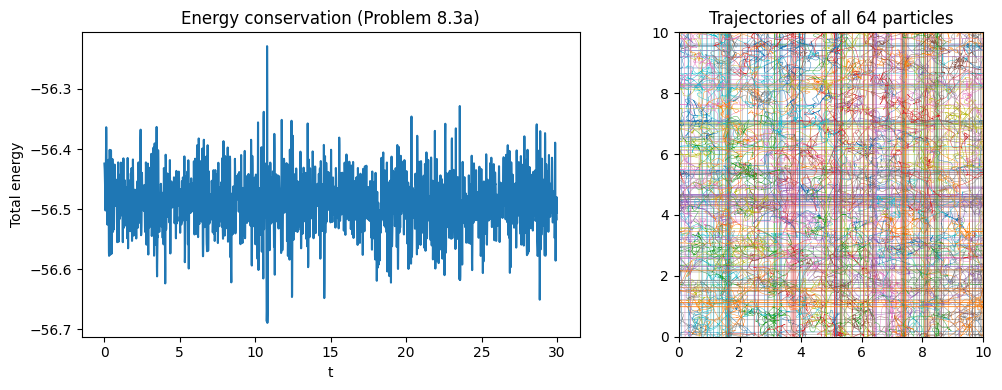

Mean total energy      = -56.4927
Std(E) / |mean E|      = 7.87e-04


In [2]:
Lx, Ly = 10.0, 10.0
N = 64

# Build an 8x8 square lattice, centered on each cell so no particle
# starts sitting on a PBC seam.
n_side = 8
spacing = Lx / n_side
xs0 = (np.arange(n_side) + 0.5) * spacing
X, Y = np.meshgrid(xs0, xs0)
x0, y0 = X.flatten(), Y.flatten()

# Random initial velocities, built in three steps:
#  1) draw uniform samples to avoid any sampling bias
#  2) subtract the mean so total momentum is zero (otherwise the whole box
#     drifts, and that drift would artificially inflate the kinetic energy)
#  3) rescale so the kinetic temperature is exactly 1.0
np.random.seed(1)
vx0 = np.random.uniform(-0.5, 0.5, N)
vy0 = np.random.uniform(-0.5, 0.5, N)
vx0 -= vx0.mean()
vy0 -= vy0.mean()
T_target = 1.0
T_now = (vx0**2 + vy0**2).sum() / (2*N)
vx0 *= np.sqrt(T_target / T_now)
vy0 *= np.sqrt(T_target / T_now)

state = make_state(x0, y0, vx0, vy0)

dt = 0.01
nsteps = 3000
t_arr, T_arr, E_arr, x_traj, y_traj = run(state, dt, nsteps)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (left) total energy vs time: should be flat modulo small fluctuations
axes[0].plot(t_arr, E_arr)
axes[0].set_xlabel('t'); axes[0].set_ylabel('Total energy')
axes[0].set_title('Energy conservation (Problem 8.3a)')

# (right) trajectories of every particle. With PBC the lines jump across
# the box, which is expected and not a bug.
for i in range(N):
    axes[1].plot(x_traj[:, i], y_traj[:, i], lw=0.3)
axes[1].set_xlim(0, Lx); axes[1].set_ylim(0, Ly)
axes[1].set_aspect('equal')
axes[1].set_title('Trajectories of all 64 particles')
plt.tight_layout(); plt.show()

print(f'Mean total energy      = {E_arr.mean():.4f}')
print(f'Std(E) / |mean E|      = {E_arr.std()/abs(E_arr.mean()):.2e}')

**Takeaway.** Total energy is conserved to a few parts in 10,000 over 30 LJ time units, which is the right order for velocity-Verlet at dt = 0.01. (Velocity-Verlet is symplectic, so there is no systematic drift; the only error is a bounded oscillation of order $dt^2$.) Every one of the 64 particles shows up in the trajectory plot, with visible PBC wraparound.

**Likely question: why Velocity-Verlet rather than RK4 or Euler?** Symplectic integrators preserve a nearby shadow Hamiltonian exactly, so they conserve energy on average without drift. RK4 is higher-order per step but slowly drifts over long runs. Euler is badly non-conservative.

## Problem 8.3(b): Kinetic temperature versus time

Using the same run as (a), plot T(t). The system starts at T = 1.0 on a lattice. The lattice is not the LJ minimum-energy configuration for this density, so potential energy shifts as the lattice relaxes, kinetic energy adjusts accordingly, and T settles into a steady fluctuating value.

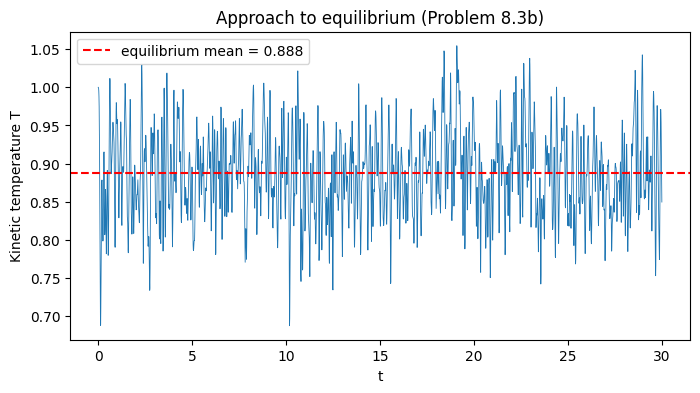

Initial T (first 10 steps) = 0.951
Equilibrium T (t > 5)      = 0.888
Std of T at equilibrium    = 0.055


In [3]:
# Discard the first 500 points (t < 5) as the transient before averaging.
equil_start = 500
T_mean = T_arr[equil_start:].mean()
T_std  = T_arr[equil_start:].std()

plt.figure(figsize=(8, 4))
plt.plot(t_arr, T_arr, lw=0.6)
plt.axhline(T_mean, color='r', ls='--',
            label=f'equilibrium mean = {T_mean:.3f}')
plt.xlabel('t'); plt.ylabel('Kinetic temperature T')
plt.title('Approach to equilibrium (Problem 8.3b)')
plt.legend(); plt.show()

print(f'Initial T (first 10 steps) = {T_arr[:10].mean():.3f}')
print(f'Equilibrium T (t > 5)      = {T_mean:.3f}')
print(f'Std of T at equilibrium    = {T_std:.3f}')

**Takeaway.** After a brief transient of about one LJ time unit the temperature settles down and fluctuates about a well-defined mean with small fluctuations. That is exactly what "equilibrium" means in a microcanonical (NVE) simulation: total energy is fixed, but the partition between KE and PE becomes steady in time.

**Likely question: why does T not stay at the initial 1.0 I set?** I fixed KE, not total energy, at t = 0. Once the lattice relaxes, some PE converts to KE (or vice versa), so KE (and hence T) drifts to its equilibrium value. If I wanted T to stay pinned I would have to rescale velocities every few steps, which is thermostatting, and this is an NVE run so I do not.

## Problem 8.3(c): Particles initially confined to the left half

Switch to a rectangular box with Lx = 20 and Ly = 10, and place all 64 particles on a lattice in the left half (x in [0, 10]). Watch it become more random with time. This is the LJ version of the free-expansion problem.

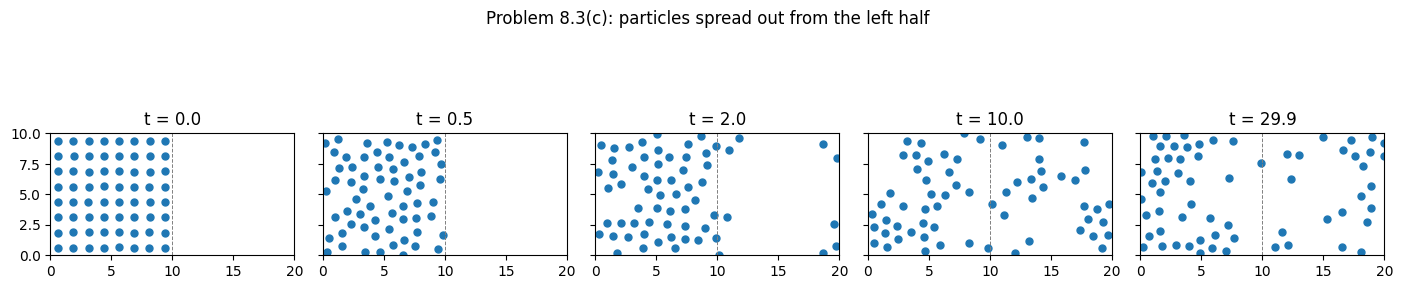

In [4]:
Lx, Ly = 20.0, 10.0
N = 64

# Same 8x8 lattice as before, but squeezed into the left 10x10 square.
spacing = 10.0 / 8
xs0 = (np.arange(8) + 0.5) * spacing     # values in [0, 10]
ys0 = (np.arange(8) + 0.5) * spacing
X, Y = np.meshgrid(xs0, ys0)
x0, y0 = X.flatten(), Y.flatten()

np.random.seed(2)
vx0 = np.random.uniform(-0.5, 0.5, N)
vy0 = np.random.uniform(-0.5, 0.5, N)
vx0 -= vx0.mean(); vy0 -= vy0.mean()
T_now = (vx0**2 + vy0**2).sum() / (2*N)
vx0 *= np.sqrt(1.0 / T_now)
vy0 *= np.sqrt(1.0 / T_now)

state = make_state(x0, y0, vx0, vy0)

dt = 0.01
nsteps = 3000
# record_every=10 just to keep the snapshot arrays small
t_arr, T_arr, E_arr, x_traj, y_traj = run(state, dt, nsteps, record_every=10)

# Five snapshots at increasing times
snap_indices = [0, 5, 20, 100, len(x_traj)-1]
fig, axes = plt.subplots(1, len(snap_indices), figsize=(14, 3.5), sharey=True)
for ax, idx in zip(axes, snap_indices):
    ax.plot(x_traj[idx], y_traj[idx], 'o', ms=5)
    ax.axvline(Lx/2, color='gray', ls='--', lw=0.7)   # mark the midline
    ax.set_xlim(0, Lx); ax.set_ylim(0, Ly)
    ax.set_aspect('equal')
    ax.set_title(f't = {t_arr[idx]:.1f}')
plt.suptitle('Problem 8.3(c): particles spread out from the left half')
plt.tight_layout(); plt.show()

**Takeaway.** The configuration becomes more random with time. The particles start in an ordered 8 by 8 lattice on the left, but thermal motion plus the strong LJ repulsion between close neighbors spreads them across the full 20 by 10 box within a few LJ time units. By the final snapshot there is no visible memory of the initial ordering. This is the microscopic view of the second law: an isolated system evolves from a lower-entropy macrostate to a higher-entropy one.

**Likely question: why is this irreversible if the underlying equations are time-symmetric?** The equations are reversible, but the special "all on the left" macrostate corresponds to an exponentially small fraction of the accessible phase space. Almost any initial microstate from that macrostate evolves into the much larger "spread out" macrostate, and the probability of spontaneously going back is negligible for any N bigger than a handful.

## Problem 8.4(a): 11 particles in a symmetric column

Eleven particles lined up at x = Lx/2, evenly spaced in y, each with velocity (1, 0). Does the system reach equilibrium?

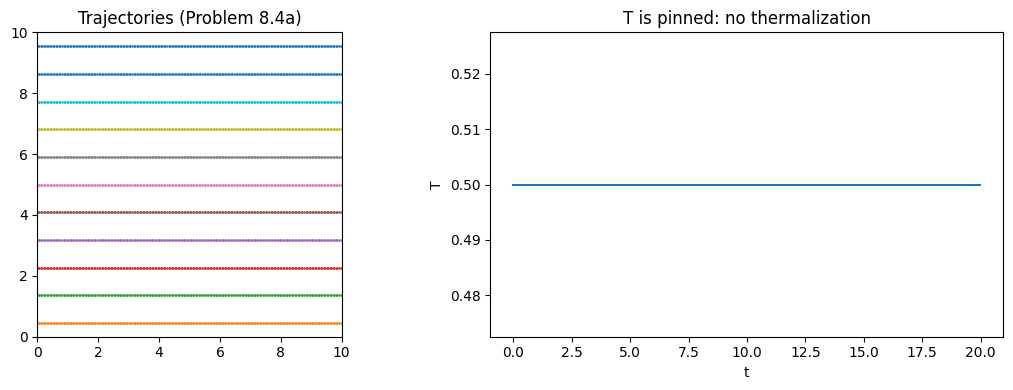

Max |vy| at end:    8.34e-13
T start / T end:    0.5000 / 0.5000


In [5]:
Lx, Ly = 10.0, 10.0
N = 11

# Exactly the initial condition from the book.
i_arr = np.arange(N)
x0 = np.full(N, Lx/2)
y0 = (i_arr - 0.5) * Ly / N     # evenly spaced under PBC (spacing = Ly/N)
vx0 = np.ones(N)                # all moving right at speed 1
vy0 = np.zeros(N)

state = make_state(x0, y0, vx0, vy0)

dt = 0.01
nsteps = 2000
t_arr, T_arr, E_arr, x_traj, y_traj = run(state, dt, nsteps, record_every=5)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (left) scatter of particle positions over time.
# Each particle traces a horizontal line wrapped by PBC.
for i in range(N):
    axes[0].plot(x_traj[:, i], y_traj[:, i], '.', ms=1)
axes[0].set_xlim(0, Lx); axes[0].set_ylim(0, Ly)
axes[0].set_aspect('equal')
axes[0].set_title('Trajectories (Problem 8.4a)')

# (right) temperature should be constant because by symmetry every particle
# feels zero net force forever, so velocities never change.
axes[1].plot(t_arr, T_arr)
axes[1].set_xlabel('t'); axes[1].set_ylabel('T')
axes[1].set_title('T is pinned: no thermalization')
plt.tight_layout(); plt.show()

print(f'Max |vy| at end:    {np.max(np.abs(state["vy"])):.2e}')
print(f'T start / T end:    {T_arr[0]:.4f} / {T_arr[-1]:.4f}')

**Takeaway.** The system does **not** reach equilibrium. Every particle sits in an identical environment: same x, and under periodic boundary conditions the y spacings to all other particles are identical for every particle. By symmetry the net force on each particle is exactly zero, so all eleven drift rightward forever at constant velocity, and the kinetic temperature is pinned at its starting value of 0.5 (KE = 0.5 * 11 * 1^2 = 5.5, so T = KE / N = 0.5).

The `max |vy|` output is around 10^-13, which is pure floating-point noise and confirms that the symmetry is held to machine precision.

**Likely question: is this a stable or unstable fixed point of the dynamics?** Unstable in the Lyapunov sense. The configuration lies on a measure-zero symmetric subspace, and any perturbation off it (as we will see in part b) grows until the system thermalizes.

## Problem 8.4(b): Tiny perturbation on particle 6

Same initial condition but with particle 6 (index 6, matching the book's 0-indexed Java loop) perturbed to vx = 0.99999, vy = 0.00001. This breaks the exact symmetry by one part in 10^5.

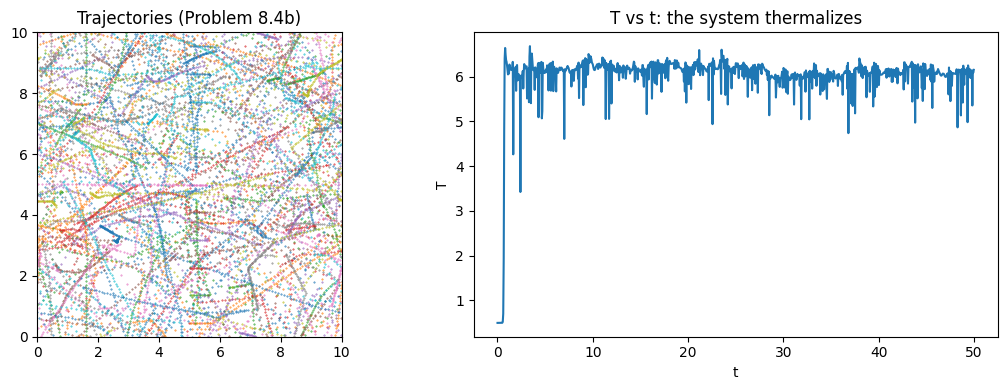

Max |vy| at end:    5.1727
T start / T end:    0.5000 / 6.1516


In [6]:
Lx, Ly = 10.0, 10.0
N = 11
i_arr = np.arange(N)
x0 = np.full(N, Lx/2)
y0 = (i_arr - 0.5) * Ly / N
vx0 = np.ones(N)
vy0 = np.zeros(N)

# Only difference from part (a):
vx0[6] = 0.99999
vy0[6] = 0.00001

state = make_state(x0, y0, vx0, vy0)

dt = 0.01
nsteps = 5000
t_arr, T_arr, E_arr, x_traj, y_traj = run(state, dt, nsteps, record_every=5)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i in range(N):
    axes[0].plot(x_traj[:, i], y_traj[:, i], '.', ms=0.8)
axes[0].set_xlim(0, Lx); axes[0].set_ylim(0, Ly)
axes[0].set_aspect('equal')
axes[0].set_title('Trajectories (Problem 8.4b)')

axes[1].plot(t_arr, T_arr)
axes[1].set_xlabel('t'); axes[1].set_ylabel('T')
axes[1].set_title('T vs t: the system thermalizes')
plt.tight_layout(); plt.show()

print(f'Max |vy| at end:    {np.max(np.abs(state["vy"])):.4f}')
print(f'T start / T end:    {T_arr[0]:.4f} / {T_arr[-1]:.4f}')

**Takeaway.** The behavior is **qualitatively** different from part (a). The one-part-in-10^5 asymmetry is amplified by the LJ interactions until the particles fully fill the box in a disordered way, just like 8.3. The final `max |vy|` is of order unity, so the y-direction velocities have grown by about 14 orders of magnitude from the perturbation size.

The temperature starts at 0.5 and climbs to a much larger equilibrium value. That happens because the initial column spacing Ly/N $\approx$ 0.91 is tighter than the LJ minimum at $r_{\min} = 2^{1/6} \approx 1.12$, so the particles start in a high-PE configuration. Once the symmetry breaks they relax outward, PE becomes more negative, and (since total E is conserved) KE has to rise.

**Sensitivity to initial conditions, and why this matters.** The trajectories in (a) and (b) differ by 10^-5 at t = 0 but are completely uncorrelated at t > 10 or so. This means the symmetric initial condition of (a) is a mathematical curiosity, not a physically realizable situation: any real preparation would have some asymmetry at least at thermal noise level, and would therefore look like (b). So almost every initial state, for a given total energy, leads to the same qualitative behavior, which is thermalization to an equilibrium characterized by that total energy alone.

**Likely question: does (b) conserve energy as well as (a)?** Yes. Total energy is still conserved by the integrator. What is not conserved is the split between kinetic and potential, and that is what allows T to change while E stays fixed.

## Problem 8.4(c): Time reversal

Run forward for some number of steps, flip every velocity, and run the same number of steps again. In exact arithmetic velocity-Verlet is time-reversible, so particles should land back on their starting positions. In floating point they do not, and the failure gets worse as we either (i) wait longer before reversing or (ii) use a larger dt.

In [7]:
def time_reversal_test(n_forward, dt, seed=3, N=64):
    """Run N=64 LJ system forward n_forward steps, reverse v, run back,
    return the PBC-aware RMS displacement from the original positions."""
    global Lx, Ly
    Lx, Ly = 10.0, 10.0

    # Same lattice + random-velocity setup as 8.3(a), wrapped in a function
    # so we can sweep n_forward and dt without duplicating code.
    n_side = int(round(np.sqrt(N)))
    spacing = Lx / n_side
    xs0 = (np.arange(n_side) + 0.5) * spacing
    X, Y = np.meshgrid(xs0, xs0)
    x_init = X.flatten(); y_init = Y.flatten()

    rng = np.random.default_rng(seed)
    vx0 = rng.uniform(-0.5, 0.5, N); vy0 = rng.uniform(-0.5, 0.5, N)
    vx0 -= vx0.mean(); vy0 -= vy0.mean()
    s = np.sqrt(1.0 / ((vx0**2 + vy0**2).sum() / (2*N)))
    vx0 *= s; vy0 *= s

    state = make_state(x_init, y_init, vx0, vy0)

    # Forward leg.
    for _ in range(n_forward):
        verlet_step(state, dt)
    # Flip the velocities. Positions are unchanged, so a_n is unchanged too.
    state['vx'] *= -1
    state['vy'] *= -1
    # Reverse leg: same integrator, just with the flipped velocities.
    for _ in range(n_forward):
        verlet_step(state, dt)

    # PBC-aware displacement from initial positions (naive subtraction
    # would be wrong for any particle that crossed a box edge).
    dx = state['x'] - x_init
    dy = state['y'] - y_init
    dx -= Lx * np.round(dx / Lx)
    dy -= Ly * np.round(dy / Ly)
    return np.sqrt(np.mean(dx**2 + dy**2))


# (i) Vary the time before reversal (book: "reverse at a later time")
print('--- Reverse at a later time (dt = 0.01 fixed) ---')
for nf in [50, 100, 500, 1000, 2000]:
    err = time_reversal_test(nf, 0.01)
    print(f'  {nf:5d} forward then back : RMS return error = {err:.2e}')

# (ii) Vary dt (book: "What happens if you choose a smaller value of dt?")
# Fixed step count means smaller dt = fewer round-off operations per unit
# physical time AND less physical time elapsed, so both effects push the
# error down.
print('\n--- Vary dt (100 forward steps then 100 back) ---')
for dt_try in [0.02, 0.01, 0.005, 0.002]:
    err = time_reversal_test(100, dt_try)
    print(f'  dt = {dt_try:<6} : RMS return error = {err:.2e}')

--- Reverse at a later time (dt = 0.01 fixed) ---
     50 forward then back : RMS return error = 1.34e-14
    100 forward then back : RMS return error = 6.25e-14
    500 forward then back : RMS return error = 2.52e-08
   1000 forward then back : RMS return error = 3.74e-01
   2000 forward then back : RMS return error = 2.87e+00

--- Vary dt (100 forward steps then 100 back) ---
  dt = 0.02   : RMS return error = 1.28e-12
  dt = 0.01   : RMS return error = 6.25e-14
  dt = 0.005  : RMS return error = 2.45e-14
  dt = 0.002  : RMS return error = 1.05e-14


**Takeaway, short forward runs.** For 50 or 100 forward steps followed by a reverse leg, the particles come back to the starting positions with RMS error of order 10^-14, which is right at double-precision machine epsilon times the box size. Velocity-Verlet is time-reversible in exact arithmetic, so the only error is floating-point round-off accumulated over a few hundred flops per step.

**Takeaway, longer forward runs.** The return error grows roughly exponentially with reversal time. By 1000 steps (t = 10) it is already 10^-1, and by 2000 steps it has saturated at of order the box size. The mechanism is: every floating-point operation introduces a random error around 10^-16, and the chaotic LJ dynamics amplifies those errors exponentially with time constant equal to the inverse of the largest Lyapunov exponent. Eventually the numerical trajectory is on a completely different orbit from the analytic one, and reversing its velocities runs the system back along that different orbit, not the one we started on.

**Takeaway, smaller dt.** With fewer floating-point operations per unit physical time and with each step closer to exact, the total round-off is smaller and the return is more reversible. The trend in the table is monotonic from dt = 0.02 down to 0.002.

**Likely question: is velocity-Verlet really time-reversible on paper?** Yes. Writing out the update for (x, v), then flipping v and running the same update, recovers x_n from x_{n+1} exactly. RK4, for comparison, is not time-reversible, so you cannot even attempt this experiment with it.

## Problem 8.4(d): Why the system is chaotic, and whether the computed trajectories are true

The two experiments above are the textbook signatures of a chaotic dynamical system:

1. **Part (b)** showed that a deliberate initial-condition perturbation of order 10^-5 leads, within a few LJ time units, to a completely different trajectory. Nearby points in phase space separate exponentially. That is the definition of a positive maximum Lyapunov exponent.

2. **Part (c)** showed the same thing from the other direction: floating-point errors at the 10^-16 level are enough to destroy time-reversal accuracy within a few LJ time units, via the same exponential amplification mechanism.

**Are the computed trajectories the true ones?** No. Round-off at every single step throws the numerical state onto a slightly different phase-space point, and those perturbations grow exponentially. After a few tens of LJ time units the computed trajectory is completely uncorrelated with the true analytic trajectory starting from the same initial conditions.

**Why molecular dynamics still works.** There is a mathematical result called the *shadowing lemma*: for a broad class of chaotic systems, even though the numerical trajectory is not a true trajectory of your specified initial condition, it is a true trajectory (or exponentially close to one) of some nearby initial condition. On top of that, the macroscopic observables we actually care about (temperature, pressure, mean energy, radial distribution function) are time averages over long trajectories and depend only on which chaotic attractor the dynamics lives on, not on the specific trajectory within it. The statistical averages therefore come out right even when every single trajectory is wrong in detail. That is what makes MD a trustworthy tool for equilibrium statistical mechanics despite the chaos.